# Imports & paths

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import timedelta
import joblib
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sksurv.metrics import integrated_brier_score
from sksurv.util import Surv

DATA_INTERIM = Path("../data/interim")
DATA_PROCESSED = Path("../data/processed")
ART_MODELS = Path("../artifacts/models")
ART_SCORES = Path("../artifacts/scores")

# Load data

In [2]:
df_txn = pd.read_parquet(DATA_INTERIM / "transactions_clean.parquet")

# Define duration and event

In [3]:
# define origin là first transaction
surv_df = (
    df_txn
    .groupby("customer_id")["transaction_date"]
    .agg(["min", "max"])
    .reset_index()
    .rename(columns={"min": "first_tx", "max": "last_tx"})
)

In [4]:
# Churn time
surv_df["event_time"] = surv_df["last_tx"] + pd.Timedelta(days=90)

In [5]:
study_end = df_txn["transaction_date"].max()

- event 1 nếu được quan sát đủ 90 ngày không có txn trước 31/12 (churn_time ≤ study_end)
- event 0 (censor) nếu chưa đủ (churn_time > study_end)

In [6]:
surv_df["event"] = (surv_df["event_time"] <= study_end).astype(int)

# Duration	= min(churn_time, study_end) − origin
surv_df["duration_days"] = (
    surv_df["event_time"]
        .where(surv_df["event"].eq(1), study_end)
    - surv_df["first_tx"]
).dt.days

In [7]:
surv_df.head()

,customer_id,first_tx,last_tx,event_time,event,duration_days
0,C00000,2025-09-10,2025-12-31,2026-03-31,0,112
1,C00001,2025-03-17,2025-12-20,2026-03-20,0,289
2,C00002,2025-08-20,2025-09-26,2025-12-25,1,127
3,C00003,2025-10-04,2025-11-18,2026-02-16,0,88
4,C00004,2025-06-08,2025-09-14,2025-12-13,1,188


# Feature Engineering

In [8]:
surv_df["tenure_days"] = (surv_df["last_tx"] - surv_df["first_tx"]).dt.days.clip(lower=0)
surv_df["recency_at_end"] = (study_end - surv_df["last_tx"]).dt.days.clip(lower=0)

In [9]:
lifetime_agg = (
    df_txn.groupby("customer_id")
    .agg(
        total_txn=("transaction_date", "count"),
        total_amount=("amount", "sum"),
    )
    .reset_index()
)

surv_df = surv_df.merge(lifetime_agg, on="customer_id", how="left")

tenure_months = (surv_df["tenure_days"] / 30.0).clip(lower=1.0)
surv_df["txn_per_month"] = surv_df["total_txn"] / tenure_months
surv_df["amount_per_month"] = surv_df["total_amount"] / tenure_months

In [10]:
end_30 = study_end - timedelta(days=30)
end_90 = study_end - timedelta(days=90)

df_recent = df_txn.assign(
    in_30d=(df_txn["transaction_date"] >= end_30),
    in_90d=(df_txn["transaction_date"] >= end_90),
)

recent_agg = (
    df_recent.groupby("customer_id")
    .agg(
        freq_30d=("in_30d", "sum"),
        freq_90d=("in_90d", "sum"),
    )
    .reset_index()
)

surv_df = surv_df.merge(recent_agg, on="customer_id", how="left")
surv_df[["freq_30d", "freq_90d"]] = surv_df[["freq_30d", "freq_90d"]].fillna(0)

surv_df["freq_ratio_30d_90d"] = surv_df["freq_30d"] / (surv_df["freq_90d"] + 1e-6)

In [11]:
surv_df.head()

,customer_id,first_tx,last_tx,event_time,event,duration_days,tenure_days,recency_at_end,total_txn,total_amount,txn_per_month,amount_per_month,freq_30d,freq_90d,freq_ratio_30d_90d
0,C00000,2025-09-10,2025-12-31,2026-03-31,0,112,112,0,12,1222.85,3.214286,327.549107,4,9,0.444444
1,C00001,2025-03-17,2025-12-20,2026-03-20,0,289,278,11,19,1228.46,2.050360,132.567626,3,8,0.375000
2,C00002,2025-08-20,2025-09-26,2025-12-25,1,127,37,96,11,910.64,8.918919,738.356757,0,0,0.000000
3,C00003,2025-10-04,2025-11-18,2026-02-16,0,88,45,43,4,114.71,2.666667,76.473333,0,4,0.000000
4,C00004,2025-06-08,2025-09-14,2025-12-13,1,188,98,108,19,2018.94,5.816327,618.042857,0,0,0.000000


In [12]:
features = [
    "tenure_days",
    "recency_at_end",
    "txn_per_month",
    "amount_per_month",
    "freq_30d",
    "freq_90d",
    "freq_ratio_30d_90d",
]

# Cox Proportional Hazards Model (lifelines)

In [13]:
cph = CoxPHFitter()
cph.fit(
    surv_df[features + ["duration_days", "event"]],
    duration_col="duration_days",
    event_col="event"
)

cph.summary


c:\Users\hoatr\AppData\Local\Programs\Python\Python39\lib\site-packages\lifelines\utils\__init__.py:1120: ConvergenceWarning: Column freq_30d have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['event'].astype(bool)
>>> print(df.loc[events, 'freq_30d'].var())
>>> print(df.loc[~events, 'freq_30d'].var())

A very low variance means that the column freq_30d completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
c:\Users\hoatr\AppData\Local\Programs\Python\Python39\lib\site-packages\lifelines\fitters\coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
tenure_days,-0.091006,0.913012,0.002699,-0.096296,-0.085716,0.908195,0.917855,0.0,-33.716670,3.294023e-249,825.440245
recency_at_end,-0.001028,0.998972,0.000516,-0.002040,-0.000017,0.997962,0.999983,0.0,-1.992100,4.636013e-02,4.430972
txn_per_month,-0.030685,0.969781,0.016026,-0.062096,0.000725,0.939792,1.000726,0.0,-1.914707,5.552984e-02,4.170593
amount_per_month,-0.000020,0.999980,0.000166,-0.000346,0.000306,0.999654,1.000306,0.0,-0.121252,9.034916e-01,0.146417
freq_30d,0.039788,1.040590,0.078269,-0.113616,0.193192,0.892601,1.213115,0.0,0.508350,6.112078e-01,0.710265
freq_90d,0.046690,1.047797,0.028149,-0.008482,0.101861,0.991554,1.107230,0.0,1.658648,9.718667e-02,3.363098
freq_ratio_30d_90d,5.747592,313.435154,0.481628,4.803619,6.691566,121.950965,805.582769,0.0,11.933677,7.900509e-33,106.641682


## Evaluation 

### Evaluate Concordance Index (C-index)

In [14]:
risk_pred = cph.predict_partial_hazard(surv_df[features])

c_index = concordance_index(
    surv_df["duration_days"],
    -risk_pred, 
    surv_df["event"]
)

print(f"C-index: {c_index:.4f}")



C-index: 0.9981


### Integrated Brier Score (IBS)

In [15]:
# =========================
# Survival predictions
# =========================
surv_funcs = cph.predict_survival_function(surv_df[features])
# surv_funcs shape: (n_times, n_samples)

# =========================
# VALID time grid (CRITICAL FIX)
# =========================
t_min = surv_df.loc[surv_df["event"] == 1, "duration_days"].min()
t_max = surv_df["duration_days"].max()

times = np.linspace(t_min, t_max * 0.999, 100)

# =========================
# Convert survival funcs
# =========================
surv_preds = np.asarray([
    np.interp(times, surv_funcs.index.values, surv_funcs.iloc[:, i].values)
    for i in range(surv_funcs.shape[1])
])
# shape: (n_samples, n_times)

# =========================
# IBS computation
# =========================
y = Surv.from_arrays(
    event=surv_df["event"].astype(bool),
    time=surv_df["duration_days"]
)

ibs = integrated_brier_score(
    y,      # train
    y,      # test
    surv_preds,
    times
)

print(f"Integrated Brier Score: {ibs:.4f}")


Integrated Brier Score: 0.0111


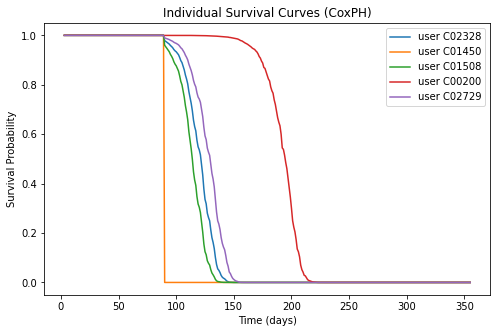

In [16]:
sample_users = surv_df.sample(5, random_state=1)

plt.figure(figsize=(8, 5))

for _, row in sample_users.iterrows():
    surv_fn = cph.predict_survival_function(row[features].to_frame().T)
    plt.plot(surv_fn.index.values, surv_fn.values.ravel(), label=f"user {row.customer_id}"
    )

plt.title("Individual Survival Curves (CoxPH)")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

## Expected lifetime

In [17]:
expected_lifetime = cph.predict_expectation(
    surv_df[features]
)

surv_df["expected_lifetime"] = expected_lifetime


## Expected remaining lifetime

In [18]:
T_days = 365
dt = 7
times = np.arange(0, T_days + dt, dt)
X_surv = surv_df[features].copy()

# Predict survival curves from origin
S = cph.predict_survival_function(X_surv, times=times)
# S: DataFrame index=times, columns aligned with rows in X_surv

# Define "now" age for each customer (days since origin=first_tx)
study_end = df_txn["transaction_date"].max()
age_now = (study_end - surv_df["first_tx"]).dt.days.values.astype(float)

# Convert to numpy for fast ops + interpolation
t_grid = S.index.values.astype(float)
S_np = S.values  # shape (len(times), N)

future_times = times.astype(float)  # remaining time grid from now (0..T)

# Interpolate S(a) for each customer
S_at_a = np.array([np.interp(a, t_grid, S_np[:, i]) for i, a in enumerate(age_now)])
S_at_a = np.clip(S_at_a, 1e-10, 1.0)

# Conditional survival S_cond(t) = S(a+t)/S(a)
S_cond = np.zeros((len(future_times), S_np.shape[1]))
for i, a in enumerate(age_now):
    S_future = np.interp(a + future_times, t_grid, S_np[:, i])
    S_cond[:, i] = S_future / S_at_a[i]

# Expected remaining lifetime (days) = integral of S_cond(t) dt
surv_df["expected_remaining_lifetime"] = np.trapz(S_cond, x=future_times, axis=0)

In [19]:
surv_df.head()

,customer_id,first_tx,last_tx,event_time,event,duration_days,tenure_days,recency_at_end,total_txn,total_amount,txn_per_month,amount_per_month,freq_30d,freq_90d,freq_ratio_30d_90d,expected_lifetime,expected_remaining_lifetime
0,C00000,2025-09-10,2025-12-31,2026-03-31,0,112,112,0,12,1222.85,3.214286,327.549107,4,9,0.444444,156.235288,47.796846
1,C00001,2025-03-17,2025-12-20,2026-03-20,0,289,278,11,19,1228.46,2.050360,132.567626,3,8,0.375000,333.912684,200.138244
2,C00002,2025-08-20,2025-09-26,2025-12-25,1,127,37,96,11,910.64,8.918919,738.356757,0,0,0.000000,119.319232,5.319576
3,C00003,2025-10-04,2025-11-18,2026-02-16,0,88,45,43,4,114.71,2.666667,76.473333,0,4,0.000000,122.265303,37.578041
4,C00004,2025-06-08,2025-09-14,2025-12-13,1,188,98,108,19,2018.94,5.816327,618.042857,0,0,0.000000,178.550276,3.617222


# Log

In [22]:

joblib.dump(cph, ART_MODELS / "survival_cox.pkl")

out = surv_df[[
    "customer_id",
    "expected_lifetime",
    "expected_remaining_lifetime"
]]

out.to_parquet(
    ART_SCORES / "survival_predictions.parquet")